In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('cleaned_fuel_economy_dataset.csv')
df

,Vehicle ID,Year,Make,Model,Class,Drive,Transmission,Engine Index,Engine Descriptor,Engine Cylinders,...,Hours to Charge (AC 240V),Composite City MPG,Composite Highway MPG,Composite Combined MPG,Range (FT1),City Range (FT1),Highway Range (FT1),City Range (FT2),Highway Range (FT2),Cost Per Mile
0,26587,1984,Alfa Romeo,GT V6 2.5,Minicompact Cars,Unknown,Manual 5-Speed,9001,(FFS),6.0,...,0.0,0,0,0,0,0.0,0.0,0.00,0.0,0.116667
1,27705,1984,Alfa Romeo,GT V6 2.5,Minicompact Cars,Unknown,Manual 5-Speed,9005,(FFS) CA model,6.0,...,0.0,0,0,0,0,0.0,0.0,0.00,0.0,0.116667
2,26561,1984,Alfa Romeo,Spider Veloce 2000,Two Seaters,Unknown,Manual 5-Speed,9002,(FFS),4.0,...,0.0,0,0,0,0,0.0,0.0,0.00,0.0,0.110000
3,27681,1984,Alfa Romeo,Spider Veloce 2000,Two Seaters,Unknown,Manual 5-Speed,9006,(FFS) CA model,4.0,...,0.0,0,0,0,0,0.0,0.0,0.00,0.0,0.110000
4,27550,1984,AM General,DJ Po Vehicle 2WD,Special Purpose Vehicle 2WD,2-Wheel Drive,Automatic 3-Speed,1830,(FFS),4.0,...,0.0,0,0,0,0,0.0,0.0,0.00,0.0,0.136667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38108,37564,2017,Volvo,XC60 FWD,Small Sport Utility Vehicle 2WD,Front-Wheel Drive,Automatic (S8),90,SIDI,4.0,...,0.0,0,0,0,0,0.0,0.0,0.00,0.0,0.090000
38109,37547,2017,Volvo,XC90 AWD,Standard Sport Utility Vehicle 4WD,All-Wheel Drive,Automatic (S8),52,SIDI,4.0,...,0.0,0,0,0,0,0.0,0.0,0.00,0.0,0.126667
38110,37548,2017,Volvo,XC90 AWD,Standard Sport Utility Vehicle 4WD,All-Wheel Drive,Automatic (S8),53,SIDI,4.0,...,0.0,0,0,0,0,0.0,0.0,0.00,0.0,0.123333
38111,37703,2017,Volvo,XC90 AWD PHEV,Standard Sport Utility Vehicle 4WD,All-Wheel Drive,Automatic (S8),54,SIDI; PHEV,4.0,...,0.0,29,32,30,0,0.0,0.0,13.84,13.3,0.113333


#### Visualizations

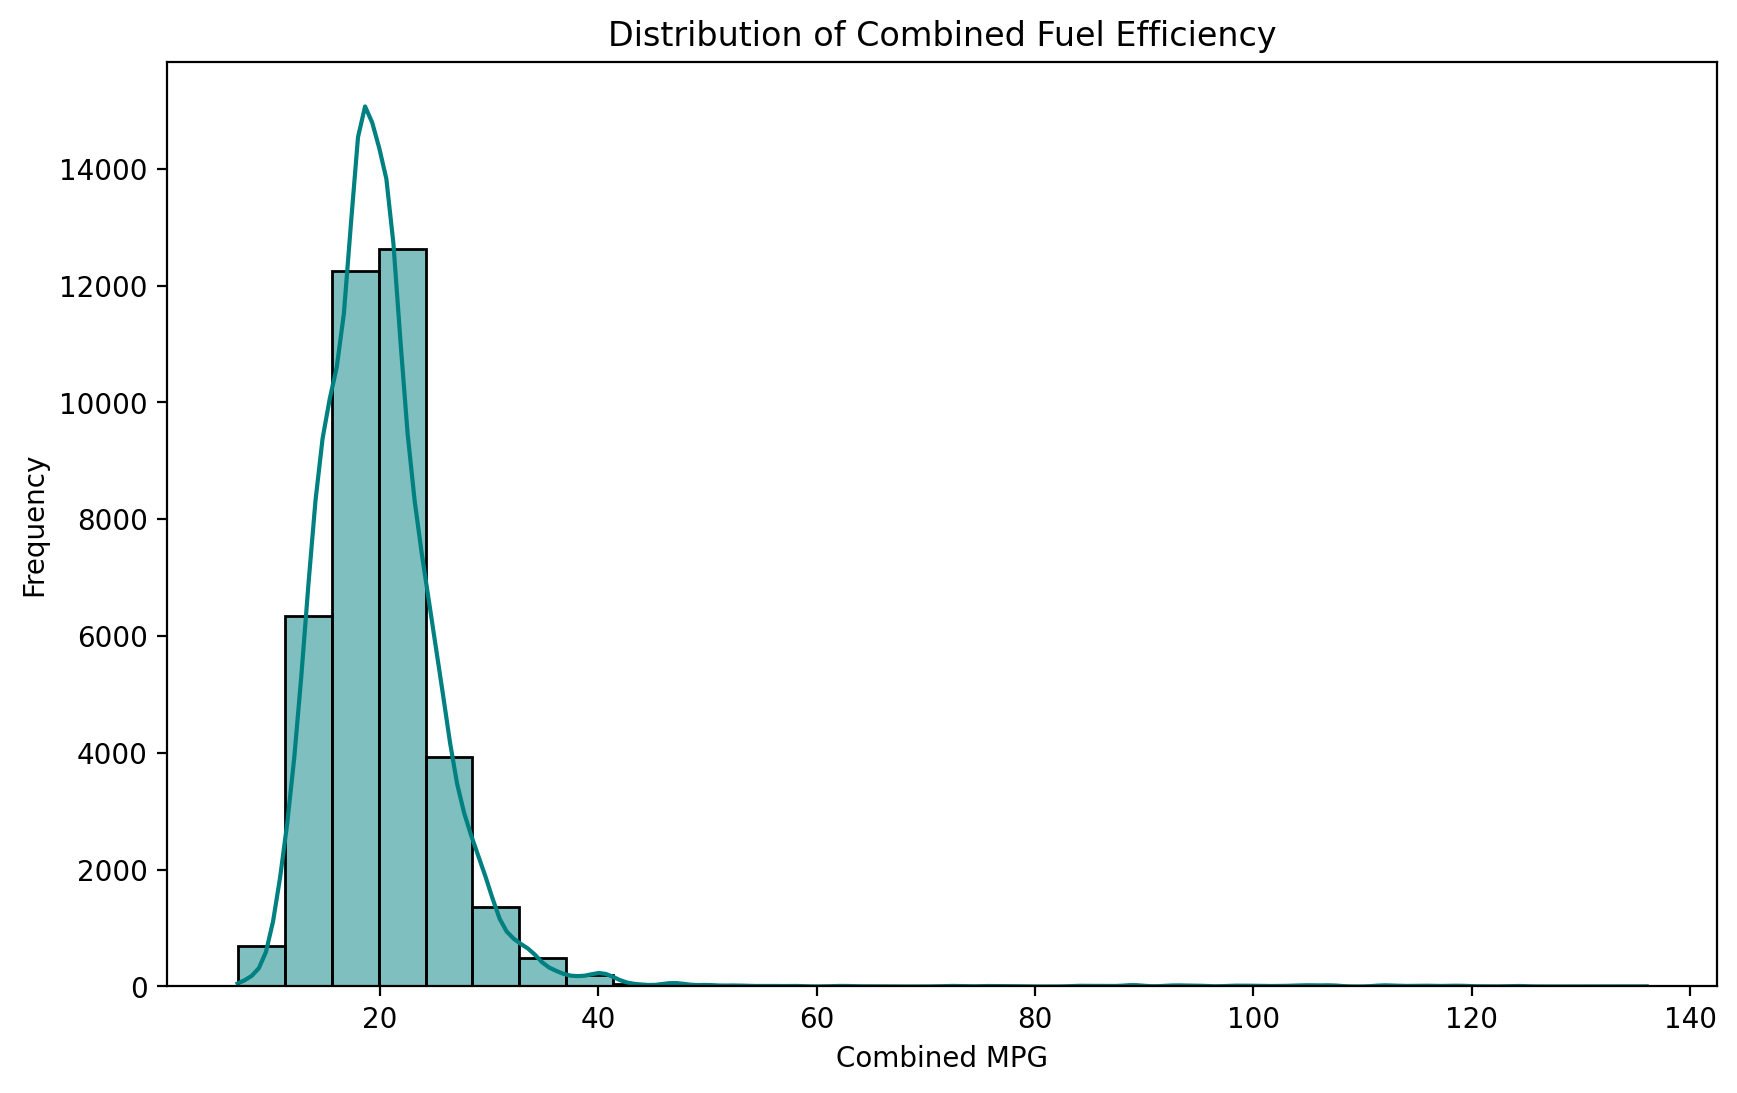

In [4]:
plt.figure(figsize=(10,6))
sns.histplot(df['Combined MPG (FT1)'], bins=30, kde=True, color='teal')
plt.title('Distribution of Combined Fuel Efficiency')
plt.xlabel('Combined MPG')
plt.ylabel('Frequency')
plt.show()

The histogram revelas a right-skewed distribution of fuel efficiency across the dataset. The vast majority of vehicle models fall within the 15 to 30 MPG range, and there is a long tail extanding toward 100+ MPG. The long tail indicates what I believe to be very efficient electric cars. As opposed to traditional engine cars, electric cars are highly efficient and deviate from the historical norm.

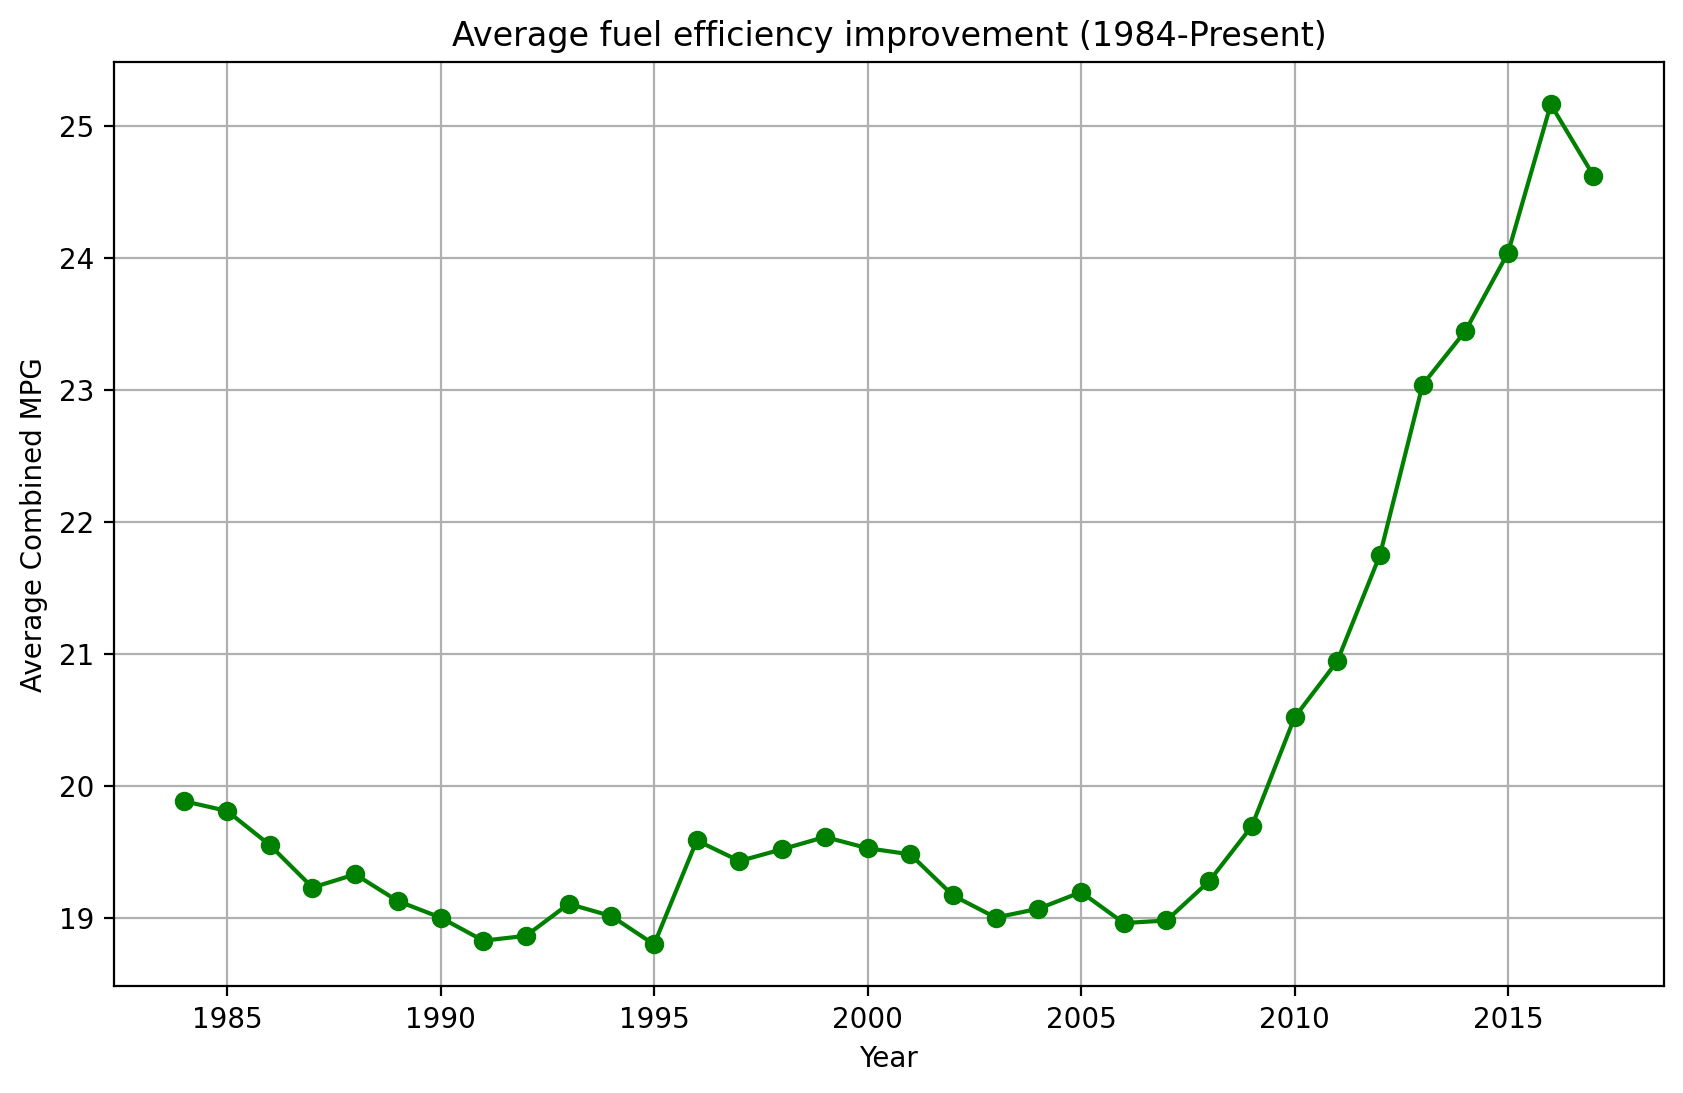

In [9]:
yearly_mpg=df.groupby('Year')['Combined MPG (FT1)'].mean()
yearly_mpg.plot(kind='line', marker='o', figsize=(10,6), color='green')
plt.title('Average fuel efficiency improvement (1984-Present)')
plt.xlabel('Year')
plt.ylabel('Average Combined MPG')
plt.grid(True)
plt.savefig('visualizations/mpg_over_time.jpg')
plt.show()

This visualization shows a trend I expected to see: increased fuel efficiency over time. This makes sense because technology improves across time, but I wanted to show it visually.

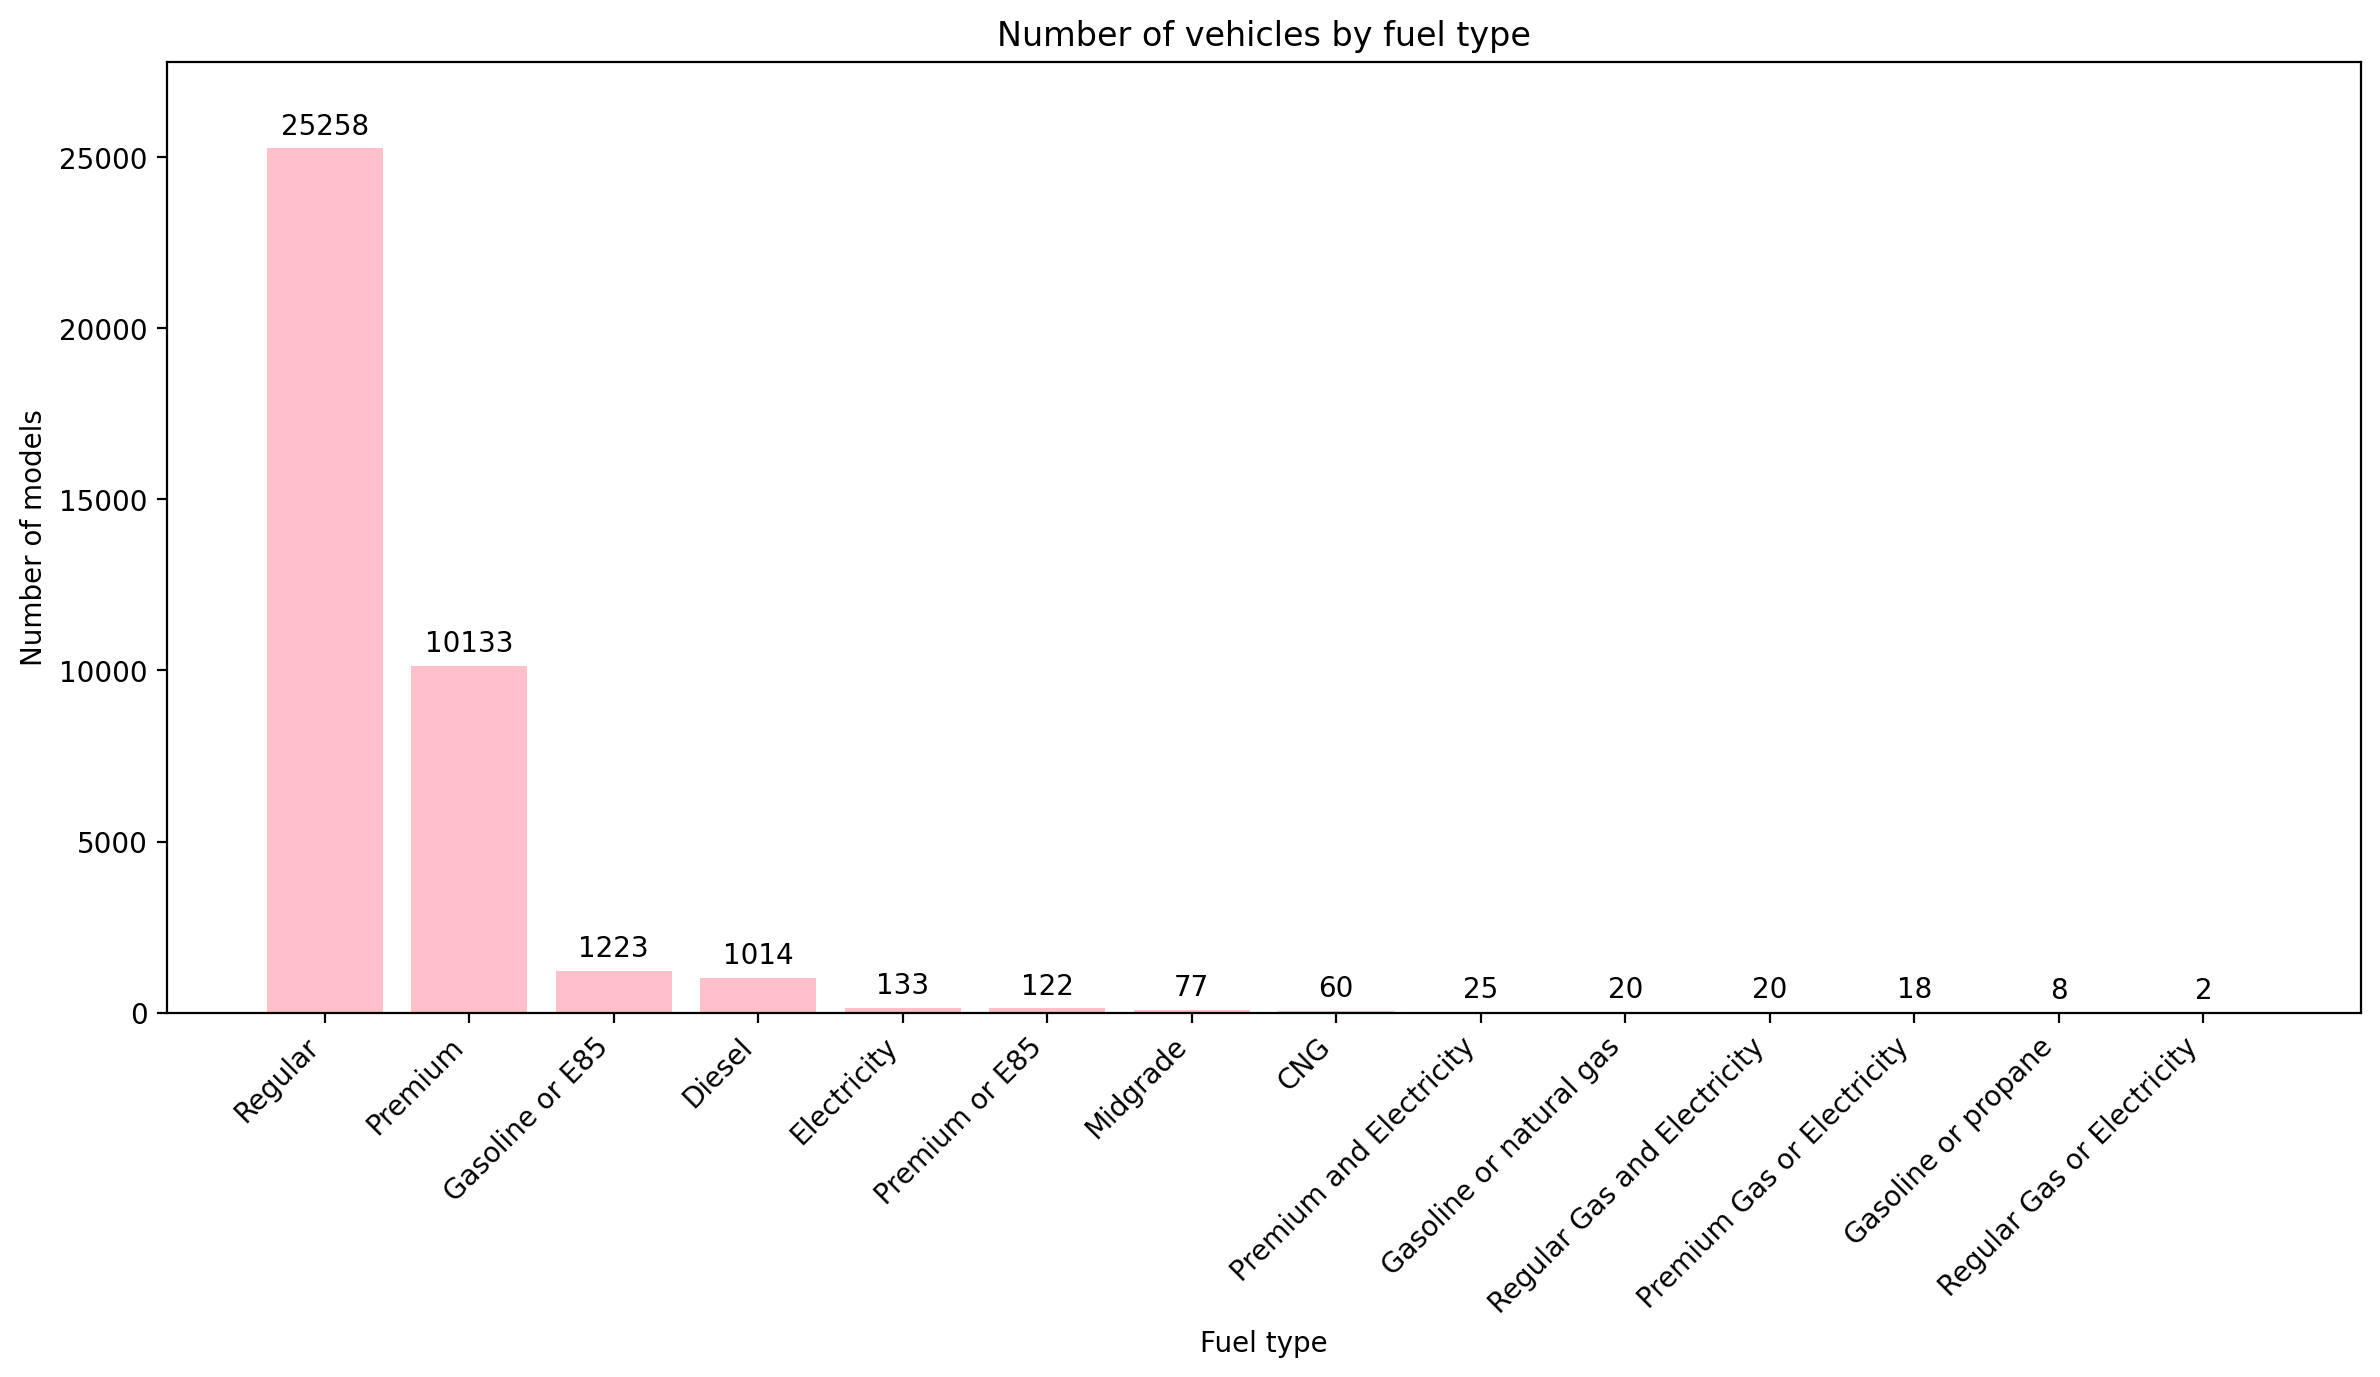

In [10]:
fuel_counts=df['Fuel Type'].value_counts().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12,7))
bars=ax.bar(fuel_counts.index, fuel_counts.values,color='pink')
ax.bar_label(bars, padding=3)
plt.title('Number of vehicles by fuel type', fontsize=12)
plt.xlabel('Fuel type')
plt.ylabel('Number of models')
plt.xticks(rotation=45, ha='right')
plt.ylim(0,fuel_counts.max() * 1.1)
plt.tight_layout()
plt.savefig('visualizations/number_of_vehicles_by_fuel_type.jpg')
plt.show()

This graph is pretty straightforward, but I thought it would be interesting to see the counts of vehicle types as this could impact my analysis. There are a significantly higher number cars that are regular fuel type than electric. This makes sense because the dataset ranges from 1984-2017, and electric cars are a new technology. Additionally, I think it serves to prove just how efficient electric cars are because the trend is observed even with such limited numbers in comparison to regular cars.

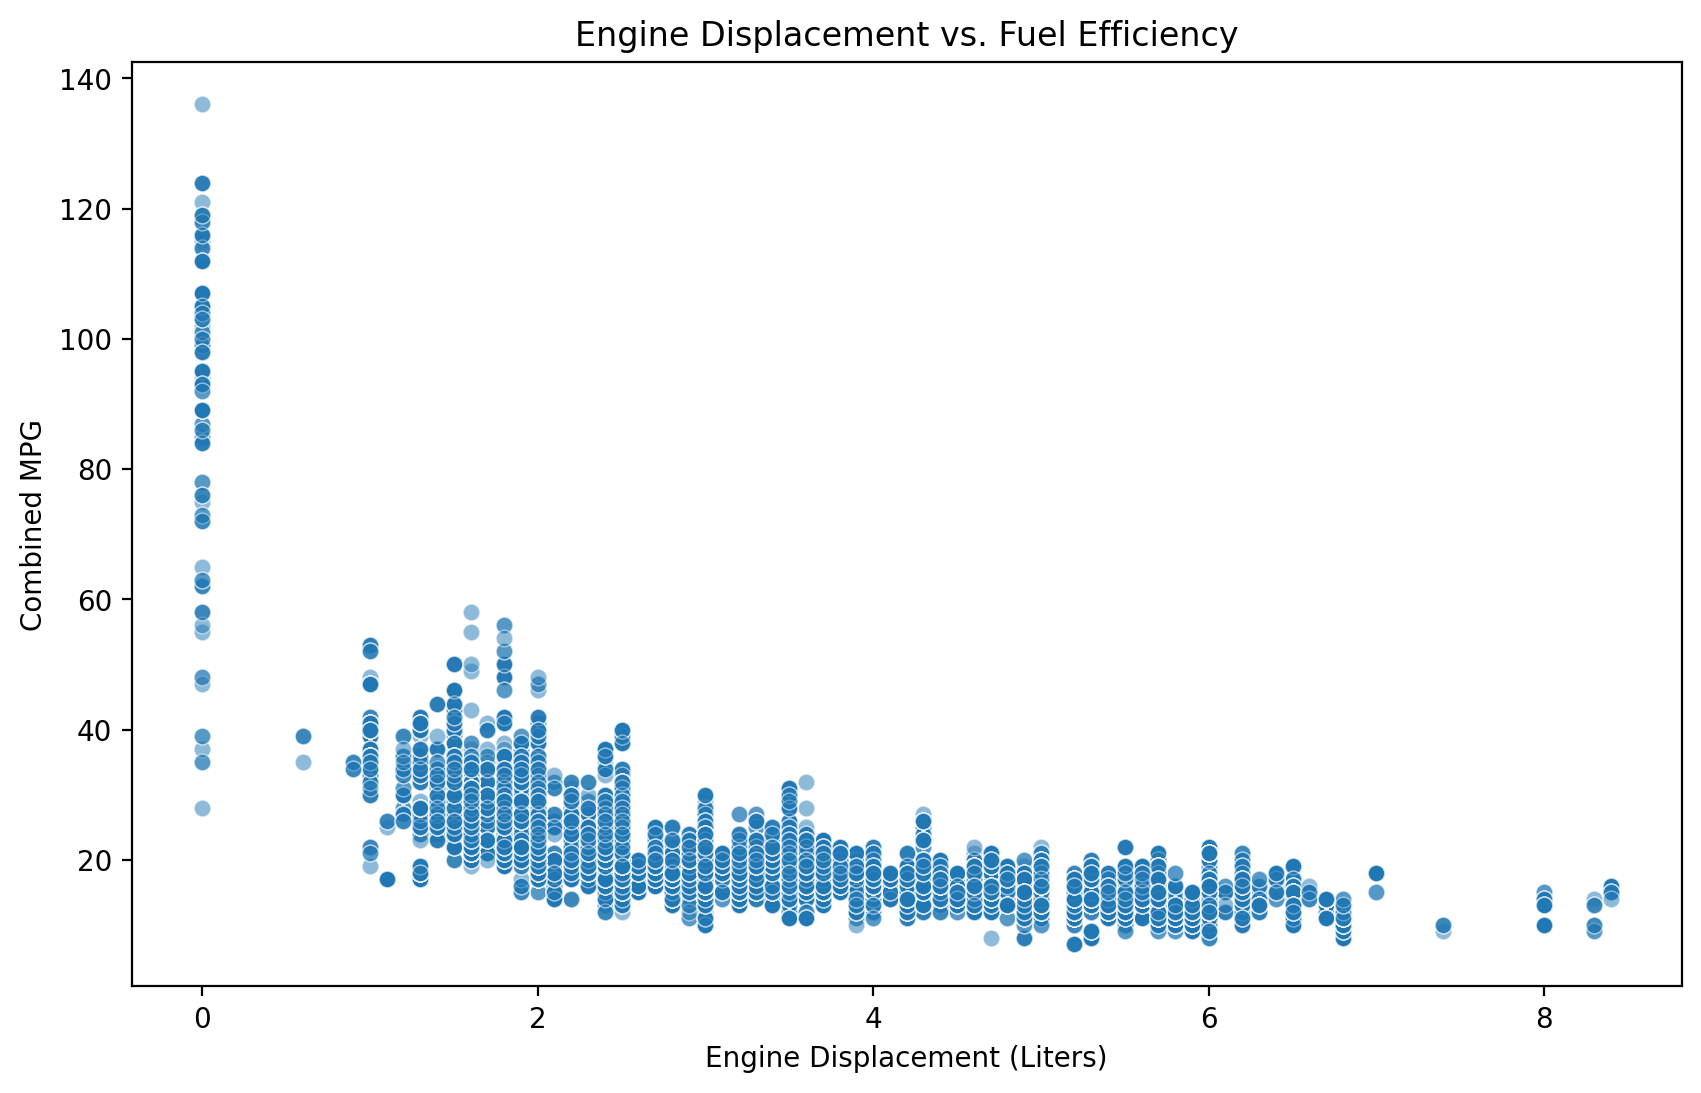

In [7]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Engine Displacement', y='Combined MPG (FT1)', alpha=0.5)
plt.title('Engine Displacement vs. Fuel Efficiency')
plt.xlabel('Engine Displacement (Liters)')
plt.ylabel('Combined MPG')
plt.savefig('visualizations/engine_displacement_vs_fuel_efficiency.jpg')
plt.show()

The scatter plot displays a negative correlation between engine dispacement (size) and fuel economy. As displacement increases, the MPG values consistently drop. The data points located at the 0 displacement mark with extremely high MPG represent the transition to electric engines. This visualizations shows that reducing engine size has historically increased fuel efficiency, but electric vehicles have done so at levels not previously reached

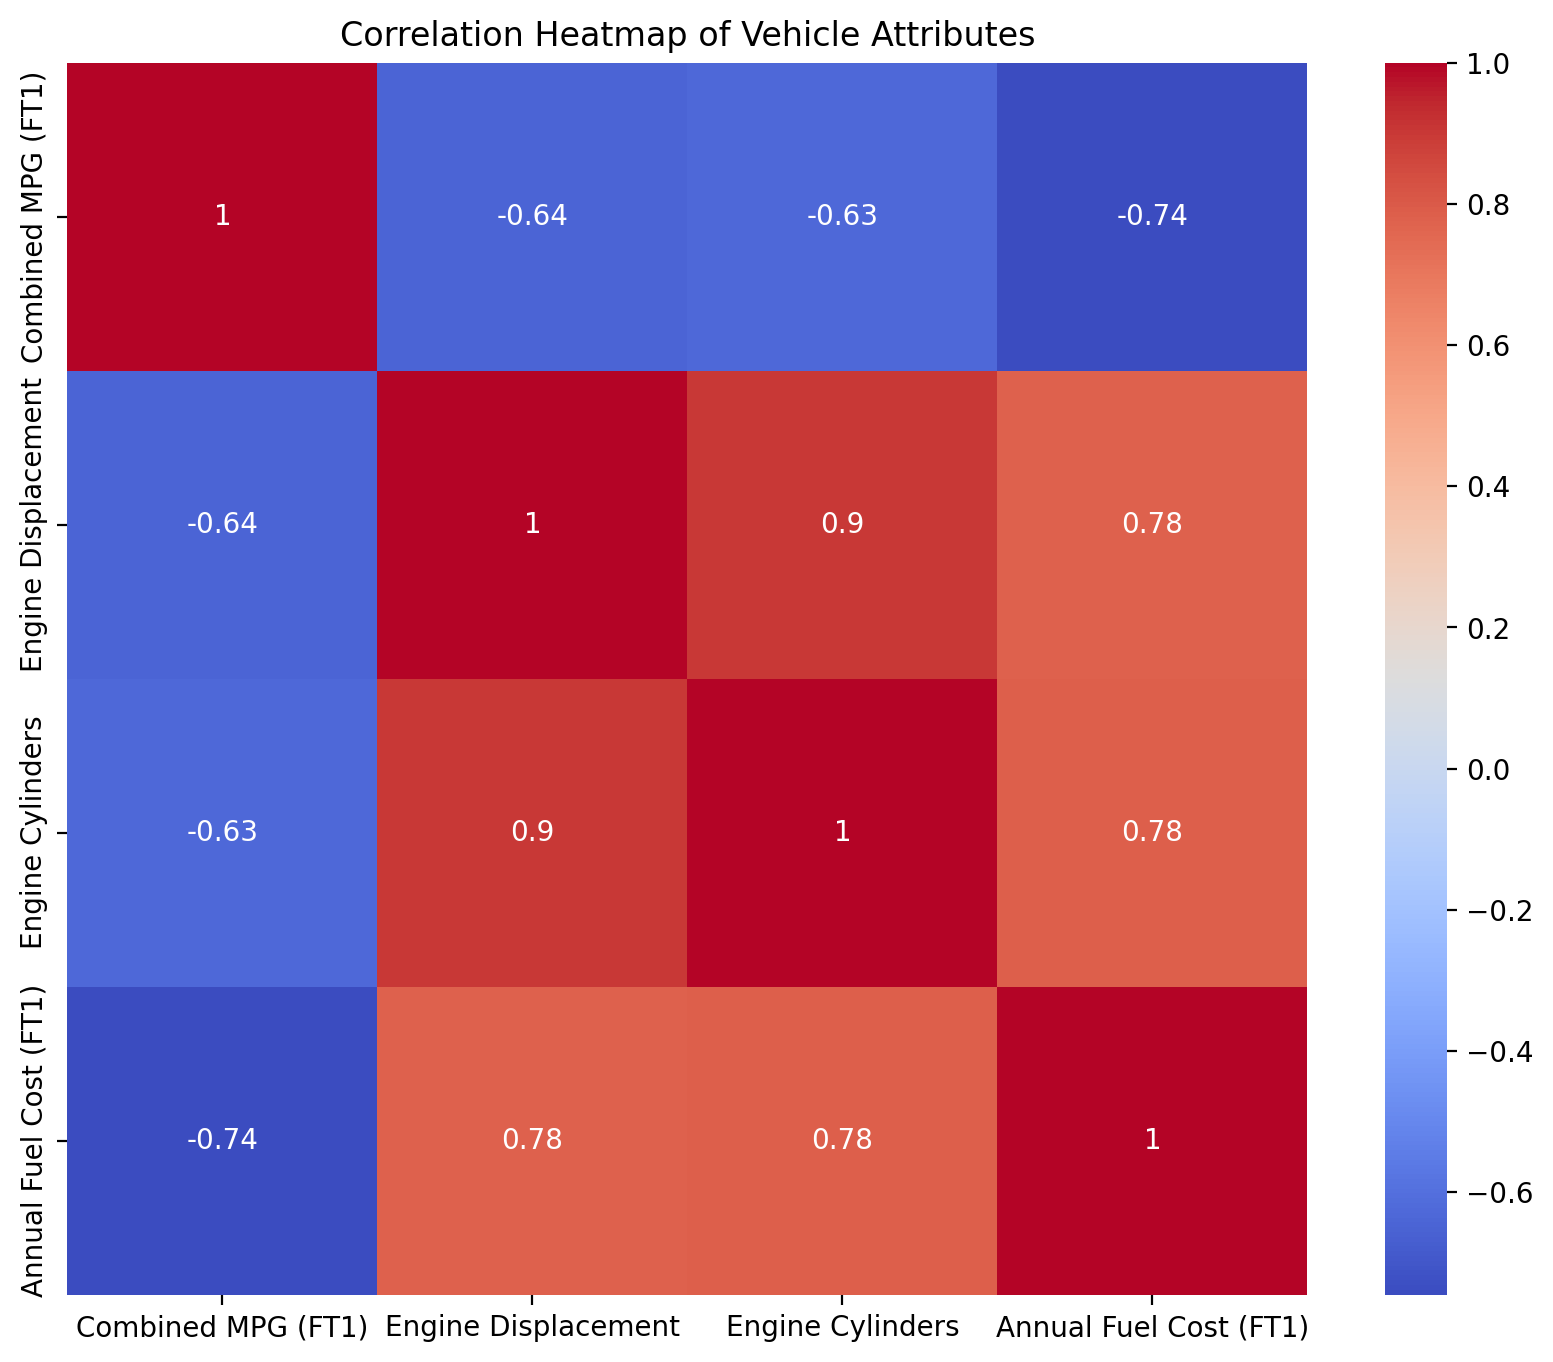

In [13]:
#i chose only a few numerical columns because there are just so many in the dataset
plt.figure(figsize=(10,8))
corr_matrix=df[['Combined MPG (FT1)', 'Engine Displacement', 'Engine Cylinders', 'Annual Fuel Cost (FT1)']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Vehicle Attributes')
plt.show()

The heatmap displays several relationships with statistical significance. Admittedly, I expected to see higher correlations with Combined MPG because that's the standard measure of efficiency, but that might be due the fact of the columns I chose to put in the heatmap. The strongest realtionship is 0.9, between Engine Displacement and Engine Cylinders. This makes sense because Engine Displacement is the total volume all cylinders can hold. Additionally, the strong negative correlation between Engine Cylinders and Combined MPG (-0.63) quantifies the efficiency penalty of larger engines. If I were curious to see more relationships, I would have to expand my matrix. While it was not very large, this heatmap provides insights on vehicle trends that influence efficiency. 

### Conclusion
Through my analysis and subsequent visualizations, we can see that the automotive industry is in a state of change. Traditional gas engines get marginally better with smaller engine displacements, but electric vehicles completely blow them out of the water on efficiency. This wasn't something I was necessarily expecting to see when I started my analysis, but it makes sense theoretically. I know my group was focused on analysing trends in 2017 alone, but I don't think that gives the complete picture. I wouldn't have been able to see the sheer magnitude of difference between electric and regular cars had I not utilized the entire dataset.